<a href="https://colab.research.google.com/github/mughesaraja/Olist-Ecommerce-Marketing-Analytics/blob/main/brazilian_ecommerce_data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

orders = pd.read_csv('olist_orders_dataset (1).csv')
orders.head()
orders.info()
orders.isnull().sum()
customers = pd.read_csv('olist_customers_dataset (1).csv')
orders.head()
orders.info()
orders.isnull().sum()
order_items = pd.read_csv('olist_order_items_dataset (1).csv')
orders.head()
orders.info()
orders.isnull().sum()
products = pd.read_csv('olist_products_dataset (1).csv')
orders.head()
orders.info()
orders.isnull().sum()
payments = pd.read_csv('olist_order_payments_dataset (1).csv')
orders.head()
orders.info()
orders.isnull().sum()
reviews = pd.read_csv('olist_order_reviews_dataset (1).csv')
orders.head()
orders.info()
orders.isnull().sum()
geolocation = pd.read_csv('olist_geolocation_dataset (1).csv')
orders.head()
orders.info()
orders.isnull().sum()
sellers = pd.read_csv('olist_sellers_dataset (1).csv')
orders.head()
orders.info()
orders.isnull().sum()
product_category = pd.read_csv('product_category_name_translation (1).csv')
orders.head()
orders.info()
orders.isnull().sum()

date_cols = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders['delivery_time'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

orders['delivery_delay'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.days

df = orders.merge(customers, on='customer_id', how='left')

df = df.merge(order_items, on='order_id', how='left')

df = df.merge(products, on='product_id', how='left')

df = df.merge(payments, on='order_id', how='left')

df = df.merge(reviews, on='order_id', how='left')

df['order_approved_at'] = df['order_approved_at'].fillna(df['order_purchase_timestamp'])

df = df.dropna(subset=['order_delivered_carrier_date'])

if df.duplicated().sum() > 0:
    df = df.drop_duplicates()

df = df.drop_duplicates()

df = df.dropna(subset=['order_delivered_customer_date'])
df['review_score'] = df['review_score'].fillna(df['review_score'].median())

df['revenue'] = df['price'] + df['freight_value']

df.info()
df.isnull().sum()

df.to_csv('cleaned_ecommerce_data.csv', index=False)
import os
os.listdir()

from google.colab import files
files.download('cleaned_ecommerce_data.csv')

Saving olist_customers_dataset.csv to olist_customers_dataset (5).csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset (5).csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset (5).csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset (5).csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset (5).csv
Saving olist_orders_dataset.csv to olist_orders_dataset (5).csv
Saving olist_products_dataset.csv to olist_products_dataset (5).csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset (5).csv
Saving product_category_name_translation.csv to product_category_name_translation (5).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
## Exploratory Data Analysis
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,delivery_delay,customer_zip_code_prefix,order_item_id,price,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_installments,payment_value,review_score,revenue
count,115721,115721,115721,115721,115721,115721.000000,115721.000000,115721.000000,115721.00000,115721.000000,...,114083.000000,115701.000000,115701.000000,115701.000000,115701.000000,115718.000000,115718.000000,115718.000000,115721.000000,115721.000000
mean,2017-12-31 09:13:58.328868608,2017-12-31 19:39:47.805566976,2018-01-03 16:05:52.828276736,2018-01-12 20:56:17.807389952,2018-01-24 05:23:06.075128832,12.022243,-12.048548,35080.263911,1.19706,119.906411,...,2.206394,2105.558846,30.238719,16.579554,23.064226,1.091274,2.940571,171.807852,4.087192,139.887790
min,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,0.000000,-147.000000,1003.000000,1.00000,0.850000,...,1.000000,0.000000,7.000000,2.000000,6.000000,1.000000,0.000000,0.000000,1.000000,6.080000
25%,2017-09-12 17:56:15,2017-09-13 03:25:43,2017-09-14 22:26:30,2017-09-22 21:53:50,2017-10-04 00:00:00,6.000000,-17.000000,11310.000000,1.00000,39.900000,...,1.000000,300.000000,18.000000,8.000000,15.000000,1.000000,1.000000,60.850000,4.000000,55.220000
50%,2018-01-18 21:06:43,2018-01-19 09:39:29,2018-01-23 17:27:35,2018-02-01 03:32:02,2018-02-15 00:00:00,10.000000,-13.000000,24320.000000,1.00000,74.900000,...,1.000000,700.000000,25.000000,13.000000,20.000000,1.000000,2.000000,108.110000,5.000000,91.790000
75%,2018-05-04 10:11:28,2018-05-04 16:30:21,2018-05-07 16:25:00,2018-05-15 00:11:47,2018-05-25 00:00:00,15.000000,-7.000000,58807.000000,1.00000,132.900000,...,3.000000,1800.000000,38.000000,20.000000,30.000000,1.000000,4.000000,188.940000,5.000000,157.220000
max,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,209.000000,188.000000,99980.000000,21.00000,6735.000000,...,20.000000,40425.000000,105.000000,105.000000,118.000000,26.000000,24.000000,13664.080000,5.000000,6929.310000
std,NaN,NaN,NaN,NaN,NaN,9.454233,10.163706,29855.176422,0.70123,182.671405,...,1.717960,3772.544888,16.126252,13.419505,11.731075,0.686743,2.776119,265.644848,1.345051,189.723731


<Axes: xlabel='order_purchase_timestamp'>

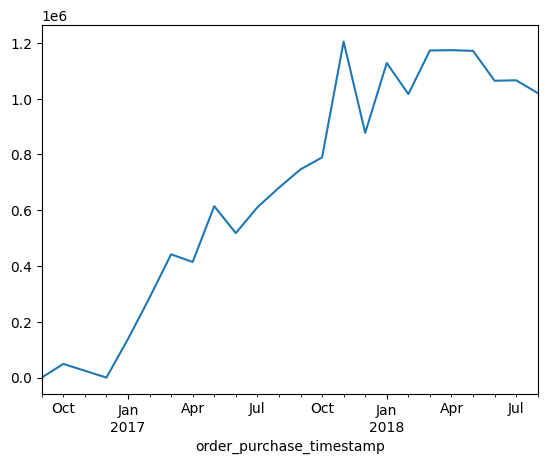

In [11]:
# Analyse monthly revenue trends
revenue_trend = df.groupby(
    df['order_purchase_timestamp'].dt.to_period('M')
)['revenue'].sum()

revenue_trend.plot()

<Axes: xlabel='product_category_name'>

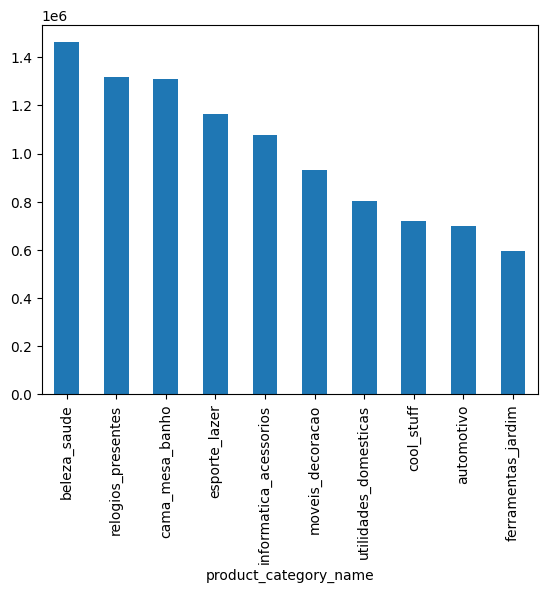

In [12]:
# Identify top-performing product categories
top_categories = df.groupby('product_category_name')['revenue'].sum().sort_values(ascending=False).head(10)

top_categories.plot(kind='bar')